# Importing Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report
from imblearn.over_sampling import SMOTE

# Loading Dataset

In [18]:
data = load_wine()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['target'] = data.target
df.head(2)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

# Input and Target

In [19]:
X = df.drop('target',axis=1)
y = df['target']



# Distribution of each column

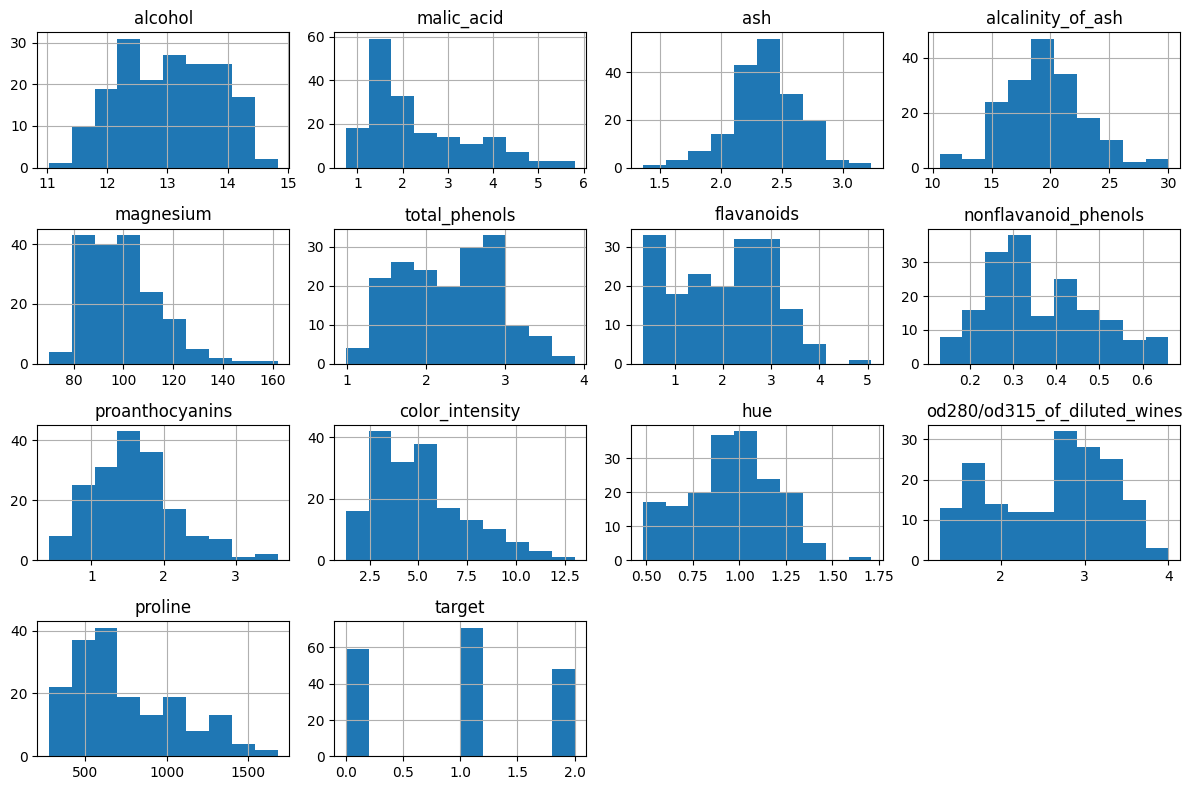

In [34]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Finding Missing values

In [20]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

# Checking Balance

<Axes: xlabel='target'>

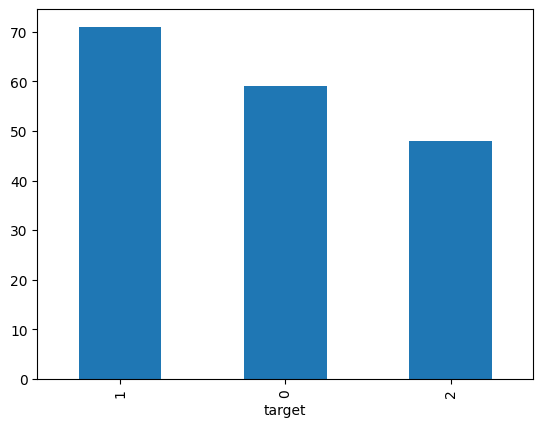

In [21]:
y.value_counts().plot(kind='bar')

# Spliting Data


In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# Scaling Data

In [23]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Balancing Data

In [24]:
smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(X_train_scaled,y_train)



# Ploting results

Text(0.5, 1.0, 'After Smote')

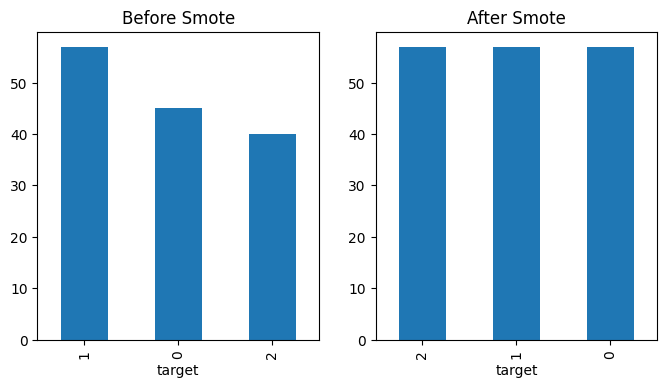

In [25]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar')
plt.title('Before Smote')

plt.subplot(1,2,2)
y_train_smote.value_counts().plot(kind='bar')
plt.title('After Smote')


# Automatically find Good parameters

In [26]:
param_grid={
    'n_neighbors':range(1,21),
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

knn = KNeighborsClassifier()

cv = StratifiedKFold(n_splits=5)

grid = GridSearchCV(estimator=knn,param_grid=param_grid,cv=cv,scoring='accuracy')

grid.fit(X_train_smote,y_train_smote)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

# Best Parameters

In [27]:
print(f'Best parameters : {grid.best_params_}')
print(f'Best Score : {grid.best_score_}')

Best parameters : {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best Score : 0.9882352941176471


# Best Model

In [28]:
best_model = grid.best_estimator_
 
y_pred = best_model.predict(X_test_scaled)



# Maually finding best k

In [29]:
# accuracy_list = []
# k_values = range(1,20)

# for k in k_values:
#     test_model = KNeighborsClassifier(n_neighbors=k)
#     test_model.fit(X_train_smote,y_train_smote)
#     y_pred_test = test_model.predict(X_test_scaled)
#     acc = accuracy_score(y_test,y_pred_test)
#     accuracy_list.append(acc)

# Ploting K vs Accuracy

In [30]:
# plt.plot(k_values,accuracy_list,marker='o')
# plt.show()

# Training Model

In [31]:
# model = KNeighborsClassifier(n_neighbors=16)
# model.fit(X_train_smote,y_train_smote)


# Prediction

In [32]:
# y_pred = model.predict(X_test_scaled)

# Report

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36

